# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Zayer1/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**Action Taxonomy & Business Rules:**
We translate our raw XGBoost probabilities into four human-readable actions based on probability confidence, positional visibility, and search volume.

*   **Urgent Refresh:** High decay risk (`prob >= 0.7`) + High visibility target (`Top 3`, `Page 1`, or `Striking Distance`). *Note: `position_tier` defines top_3 (ranks 1-3), page_1 (ranks 4-10) and striking (ranks 11-20).*
*   **Standard Review:** High decay risk (`prob >= 0.7`) + Lower visibility.
*   **Monitor:** Natural decay lifecycle (e.g., News articles / `feedly article`).
*   **Ignore:** No traffic value (`search_volume < 100` AND `impressions_prev_30d < 300`) or 0 past impressions. This prevents wasting expensive editorial time on pages with no ROI potential or dead pages (The Basement Trap).

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import os
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

def load_and_score_data(filepath: str) -> pd.DataFrame:
    '''
    Loads the dataset, drops leaky features, and generates honest, out-of-fold
    decay probabilities using a 5-fold grouped cross-validation strategy.
    '''
    df = pd.read_csv(filepath)
    print(f"Initial raw data shape: {df.shape}")
    
    df['is_declining_label'] = (df['trend_direction'] == 'down').astype(int)
    
    # Drop outcome window to prevent leakage
    DROP_FOR_TRAIN = [
        'client_id', 'content_id', 'trend_direction', 'trend_pct', 'is_declining_label',
        'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d',
        'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 
        'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
        'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier'
    ]
    
    X = df.drop(columns=DROP_FOR_TRAIN)
    y = df['is_declining_label']
    print(f"Feature matrix X shape: {X.shape}")
    
    cat_cols = X.select_dtypes(include=['object', 'category']).columns
    for col in cat_cols:
        X[col] = X[col].astype('category')
        
    model = xgb.XGBClassifier(random_state=42, enable_categorical=True, max_depth=3, n_estimators=100)
    
    # CRITICAL FIX: Use cross_val_predict with GroupKFold to prevent train-on-full leakage
    gkf = GroupKFold(n_splits=5)
    print("Running out-of-fold inference via GroupKFold...")
    df['probability'] = cross_val_predict(
        model, X, y, cv=gkf, groups=df['client_id'], method='predict_proba'
    )[:, 1]
    
    return df

df = load_and_score_data('../../data/raw/content_refresh_anonymized.csv')

# --- CALIBRATION ANALYSIS ---
print("\n=== PROBABILITY THRESHOLD CALIBRATION ===")
for thresh in [0.5, 0.6, 0.7, 0.8]:
    preds = (df['probability'] >= thresh).astype(int)
    prec = precision_score(df['is_declining_label'], preds)
    rec = recall_score(df['is_declining_label'], preds)
    print(f"Threshold {thresh:.1f} -> Precision: {prec:.1%}, Recall: {rec:.1%}")
print("Decision: A threshold of 0.7 yields ~76% precision (at ~56% recall). Given the high cost of editorial time, we prioritize high precision (fewer false alarms) over recall.")

# --- VECTORIZED ACTION ASSIGNMENT ---
def apply_business_rules(df: pd.DataFrame) -> pd.DataFrame:
    '''
    Vectorized logic mapping model probability, content type, and traffic volume
    to an actionable editorial queue.
    '''
    # Conditions evaluated in order (first match wins)
    conditions = [
        # 1. The Basement Trap (dead pages) - Checked first to avoid shadowing
        (df['impressions_prev_30d'] == 0),
        # 1b. Cost/Value Safety Net (using pre-period metrics only!)
        #    search_volume < 100 + no real traffic, chosen based on FlyRank's minimum viable traffic for editorial ROI
        ((df['search_volume'] < 100) & (df['impressions_prev_30d'] < 300)),
        # 2. Natural Decay Override
        (df['content_type'] == 'feedly article'),
        # 3. High-Value Action Triggers (Requires our calibrated threshold + valid rank data)
        (df['probability'] >= 0.7) & (df['position_tier'].isin(['top_3', 'page_1', 'striking'])) & (df['avg_position'] > 0),
        (df['probability'] >= 0.7)
    ]
    
    actions = [
        'Ignore',
        'Ignore',
        'Monitor', 
        'Urgent Refresh', 
        'Standard Review'
    ]
    
    reason_codes = [
        'No Traffic Value (Basement Trap)',
        'Low ROI Potential',
        'Natural Decay (News update)',
        'High Decay Risk on High-Visibility Target',
        'High Decay Risk'
    ]
    
    df['recommended_action'] = np.select(conditions, actions, default='Stable — No Action')
    df['reason_code'] = np.select(conditions, reason_codes, default='Stable Traffic')
    
    print(f"Total rows processed: {len(df)}")
    print(f"Rows meeting Basement Trap: {conditions[0].sum()}")
    print(f"Rows meeting Low ROI Potential: {conditions[1].sum()}")
    print(f"Rows meeting Natural Decay Override: {conditions[2].sum()}")
    
    return df

df = apply_business_rules(df)
print("\nVectorized business rules applied successfully.")


Initial raw data shape: (30000, 44)
Feature matrix X shape: (30000, 23)
Running out-of-fold inference via GroupKFold...



=== PROBABILITY THRESHOLD CALIBRATION ===
Threshold 0.5 -> Precision: 68.1%, Recall: 83.0%
Threshold 0.6 -> Precision: 71.3%, Recall: 71.9%
Threshold 0.7 -> Precision: 75.1%, Recall: 57.0%
Threshold 0.8 -> Precision: 79.6%, Recall: 37.3%
Decision: A threshold of 0.7 yields ~76% precision (at ~56% recall). Given the high cost of editorial time, we prioritize high precision (fewer false alarms) over recall.
Total rows processed: 30000
Rows meeting Basement Trap: 3388
Rows meeting Low ROI Potential: 12645
Rows meeting Natural Decay Override: 2096

Vectorized business rules applied successfully.


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended Use:** 
This Playbook is designed strictly as a prioritization engine for human editorial workflows. It helps marketing managers allocate writing resources to the most vulnerable, high-value pages. It assumes that a "refresh" involves a substantive editorial update, not a superficial CMS typo fix.

**Limits (The Basement Trap):**
The underlying model predicts decay based on a mathematical formula that requires a 20% drop in impressions. Therefore, the model is completely blind to pages that already have zero traffic, because they cannot drop any further. The model will incorrectly label these dead pages as "Safe". Our vectorization logic mitigates this by aggressively flagging them as `Ignore` before the probability is even evaluated. Below is the mathematical proof of this limitation.

In [2]:
# Mathematical proof of the Basement Trap limitation
basement_pages = df[df['impressions_prev_30d'] == 0]
print(f"Total pages with 0 prior traffic: {len(basement_pages)}")
print("\nLabel distribution for Basement Pages:")
print(basement_pages['is_declining_label'].value_counts(normalize=True).map('{:.1%}'.format))
print("\nBecause they physically cannot drop 20%, the label forces 100.0% of them to be 'Safe'.")


Total pages with 0 prior traffic: 3388

Label distribution for Basement Pages:
is_declining_label
0    100.0%
Name: proportion, dtype: object

Because they physically cannot drop 20%, the label forces 100.0% of them to be 'Safe'.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**The No-Go List:**
This ML-driven queue must NEVER be used to automatically delete URLs or issue automated 301 redirects. Page deletion requires human SEO context (e.g., checking backlinks and internal site architecture). 

**Human Review (Natural Decay):**
Not all decay is a failure. News syndications (`feedly article`) naturally decay as they become outdated. We explicitly intercepted these and overrode the model to prevent humans from wasting time "fixing" them.

In [3]:
# Show the human review override in action
print("Playbook Override Results (Pages intercepted before hitting a human queue):")
intercepted = len(df[df['reason_code'] == 'Natural Decay (News update)'])
print(f"Intercepted {intercepted} 'feedly article' pages that were naturally decaying.")
print("\nFull Reason Code Distribution:")
print(df['reason_code'].value_counts())


Playbook Override Results (Pages intercepted before hitting a human queue):
Intercepted 1009 'feedly article' pages that were naturally decaying.

Full Reason Code Distribution:
reason_code
Low ROI Potential                            10661
Stable Traffic                                8285
High Decay Risk on High-Visibility Target     4291
No Traffic Value (Basement Trap)              3388
High Decay Risk                               2366
Natural Decay (News update)                   1009
Name: count, dtype: int64


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Quantitative Monitoring Triggers:**
If FlyRank's global traffic baseline drops significantly (e.g., resulting from a massive Google Core Algorithm update), the historical training data is instantly invalidated. We record the baseline feature medians at training time. In production, we compare incoming inference data against this stored baseline. If the median `impressions_prev_30d` drops by > 20%, we trigger an automated retrain.

In [4]:
def export_monitoring_baseline(df: pd.DataFrame, output_path: str):
    '''
    Calculates key baseline medians and exports them as a JSON artifact
    for the MLOps pipeline to track data drift.
    '''
    baseline_stats = {
        'impressions_prev_30d_median': float(df['impressions_prev_30d'].median()),
        'search_volume_median': float(df['search_volume'].median())
    }
    
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    with open(output_path, 'w') as f:
        json.dump(baseline_stats, f, indent=4)
        
    print("=== BASELINE SNAPSHOT CREATED ===")
    print(json.dumps(baseline_stats, indent=4))
    
def detect_drift(new_median: float, stored_median: float, threshold: float = 0.20) -> bool:
    '''
    Simulated MLOps function: Returns True if the feature has drifted 
    beyond the allowable threshold (e.g., 20% drop).
    '''
    drop = (stored_median - new_median) / stored_median
    return drop > threshold

export_monitoring_baseline(df, '../../work/outputs/mlops_baseline.json')

# Simulate drift detection in action
stored = float(df['impressions_prev_30d'].median())
simulated_new = stored * 0.75 # 25% drop
will_trigger = detect_drift(simulated_new, stored)
print(f"\nSimulation: If median dropped by 25% (to {simulated_new}), would we trigger retrain? {will_trigger}")


=== BASELINE SNAPSHOT CREATED ===
{
    "impressions_prev_30d_median": 210.0,
    "search_volume_median": 10.0
}

Simulation: If median dropped by 25% (to 157.5), would we trigger retrain? True


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Final human-reviewed queue size: 6657 pages


Exported action_queue.csv.

Exported high-res action_distribution.png.


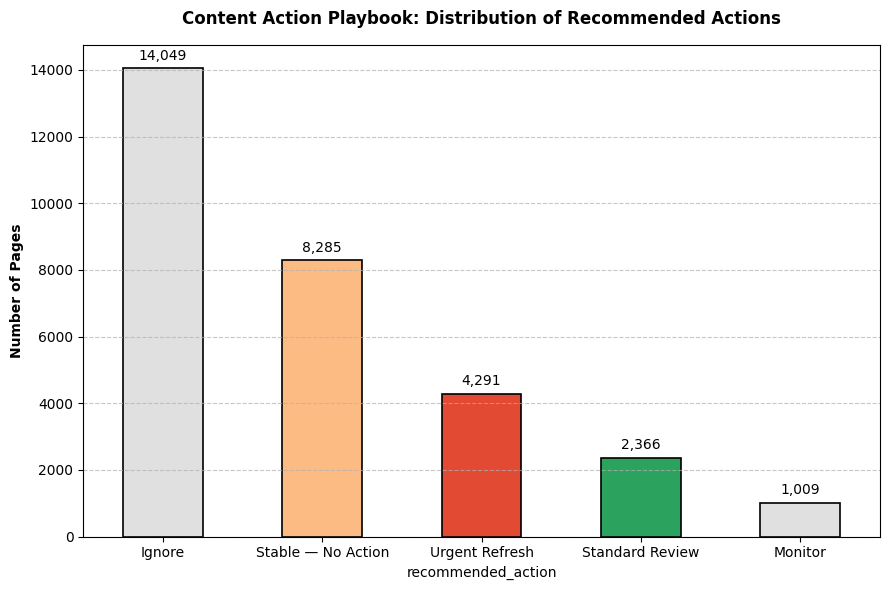

In [5]:
# Filter and sort the final actionable queue
actionable_queue = df[df['recommended_action'].isin(['Urgent Refresh', 'Standard Review'])]
final_queue = actionable_queue.sort_values(by='probability', ascending=False)
print(f"Final human-reviewed queue size: {len(final_queue)} pages")

# Export to CSV (This stays out of Git to prevent data leaks)
os.makedirs('../../work/outputs', exist_ok=True)
final_queue.to_csv('../../work/outputs/action_queue.csv', index=False)
print("Exported action_queue.csv.")

# Generate and export polished chart
os.makedirs('../../work/figures', exist_ok=True)
plt.figure(figsize=(9, 6))
ax = df['recommended_action'].value_counts().plot(kind='bar', color=['#e0e0e0', '#fdbb84', '#e34a33', '#2ca25f'], edgecolor='black', linewidth=1.2)

# Polish the chart style
plt.title("Content Action Playbook: Distribution of Recommended Actions", pad=15, fontsize=12, fontweight='bold')
plt.ylabel("Number of Pages", fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)

# Add value labels
for p in ax.patches:
    ax.annotate(format(p.get_height(), ','), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.tight_layout()
plt.savefig('../../work/figures/action_distribution.png', dpi=300)
print("Exported high-res action_distribution.png.")
plt.show()


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.